# Graph Neural Networks for Recommender Systems (Version 2)

This notebook builds directly on Part 1 — Embeddings. There, we compressed sparse user–item data into dense vectors. Here, we show how graphs can make those embeddings even better by leveraging neighborhood structure (who is connected to whom and how).

What you'll do:
- Understand graphs and why many RS problems are naturally graph-shaped
- Reframe MovieLens as a bipartite user–item graph
- Learn the intuition behind Graph Neural Networks (GNNs) and message passing
- Implement a LightGCN-style propagation in PyTorch (minimal, dependency-light)
- Preview how PyTorch Geometric represents graphs and drives link prediction
- See a real-world success case: Pinterest PinSage

In [1]:
# Imports and setup
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy import sparse
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline
plt.style.use('default')
sns.set_palette('husl')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

data_path = "../data/ml-latest-small"


### How this builds on Part 1 (Embeddings)

In Part 1, we saw how matrix factorization techniques like SVD and NMF can compress sparse user-item matrices into dense, meaningful embeddings. We also explored how simple neural models can create context-based embeddings from item metadata.

Now, we'll take this a step further. Instead of learning embeddings in isolation, we will refine them by allowing nodes in the user-item interaction graph to borrow information from their neighbors. This process, known as message passing, helps capture the collaborative effects that are crucial for high-quality recommendations.

The ultimate goal is to produce powerful, link-prediction-ready embeddings. By computing the dot product of these refined user and item embeddings, we can predict connections (i.e., recommendations) and seamlessly integrate them into ranking and content search systems.


## 1) What is a Graph? A Quick Refresher

At its core, a graph is a simple but powerful structure composed of **nodes** (representing entities) and **edges** (representing the relationships between them). The key insight for recommender systems is that a vast amount of real-world data naturally fits this model.

Think of social networks (friends and followers), road networks, or even molecules. In our domain, the most important example is users interacting with items. To make these concepts more concrete, we'll use the `networkx` library to visualize a few small, illustrative graphs.

Degrees in triangle: {1: 2, 2: 2, 3: 2}
Degrees in star: {0: 5, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1}


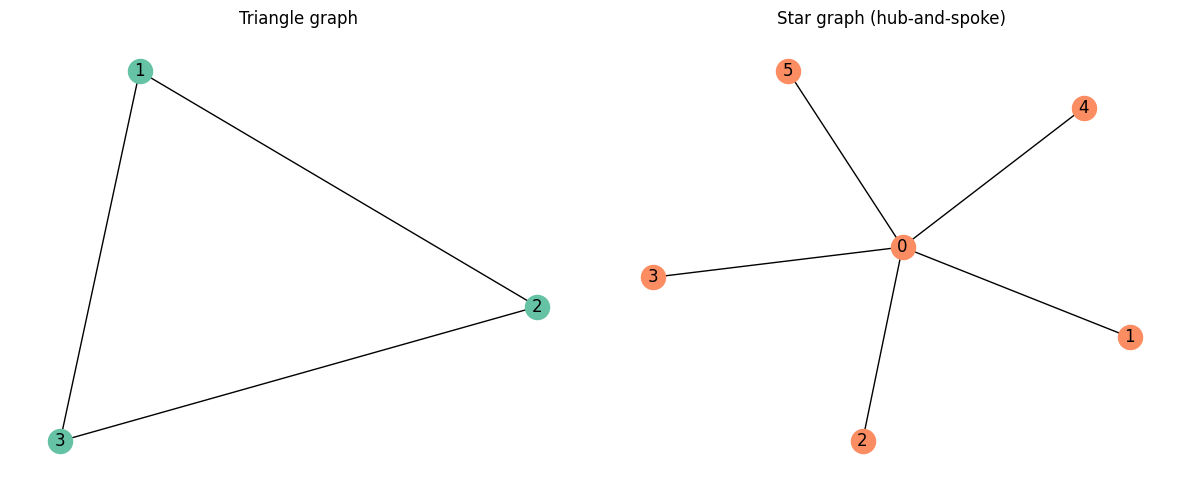

In [2]:
# Tiny graph demos with NetworkX
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Example A: triangle (3 nodes, everyone connected)
G1 = nx.Graph()
G1.add_edges_from([(1, 2), (2, 3), (1, 3)])
pos1 = nx.spring_layout(G1, seed=SEED)
nx.draw(G1, pos1, with_labels=True, node_color='#66c2a5', ax=axes[0])
axes[0].set_title('Triangle graph')

# Example B: star (one hub, many spokes)
G2 = nx.Graph()
center = 0
G2.add_nodes_from(range(6))
G2.add_edges_from([(center, i) for i in range(1, 6)])
pos2 = nx.spring_layout(G2, seed=SEED)
nx.draw(G2, pos2, with_labels=True, node_color='#fc8d62', ax=axes[1])
axes[1].set_title('Star graph (hub-and-spoke)')

plt.tight_layout()

print('Degrees in triangle:', dict(G1.degree()))
print('Degrees in star:', dict(G2.degree()))

### Reading Graph Visuals Like a Recommender Scientist

When we visualize a graph, we're gaining intuition about how information will flow through our recommender system. Key properties give us clues about its behavior. For instance, a node's **degree**—how many connections it has—signals its influence. High-degree "hubs" often represent popular items or very active users, and they play a crucial role in spreading information across the network.

The overall **connectivity** also matters. Short paths between nodes enable multi-hop influence, where "friends of friends" effects can be captured, which is vital for sophisticated ranking. Furthermore, the local **structure**, such as the difference between a star-shaped graph and a dense triangle, hints at how information will propagate. A hub can broadcast its influence widely, while a triangle reinforces similarities within a small group.

Ultimately, observing these patterns gives us a preview of the core mechanism of Graph Neural Networks: **message passing**. How a node's embedding is refined is directly shaped by the structure of its neighborhood, making these visual interpretations a valuable

## 2) Recommender Systems as Graphs

The core insight that unlocks the power of GNNs for recommendations is surprisingly simple: user-item interactions can be naturally represented as a **bipartite graph**. This reframes our familiar MovieLens dataset, shifting the perspective from a sparse matrix to a rich, interconnected network.

While the matrix view is excellent for linear algebra, it obscures the underlying topology. By adopting a graph perspective, we can explicitly model the connections between users and items. This allows us to capture complex, multi-hop relationships—such as "users who liked items that were also liked by similar users"—that classical matrix factorization techniques often miss. We'll compare these two views side-by-side to build intuition for why this structural approach is so powerful.

Dataset info:
Ratings: (100004, 4), Movies: (9125, 3)
Users: 671, Items: 9066
Interactions: 100004
Subset: 45 users x 200 items, 630 interactions (rating >= 4)


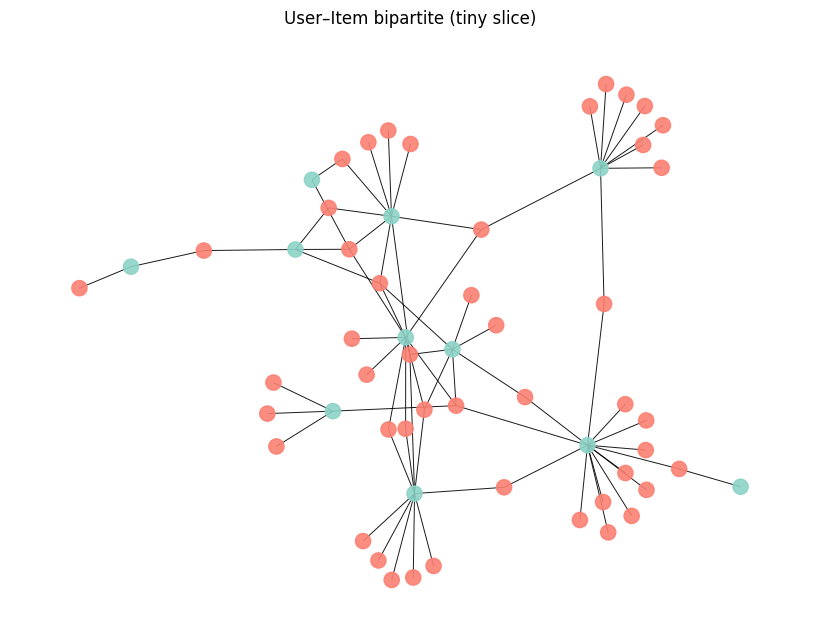

In [ ]:
# Load MovieLens and build implicit interactions (rating >= 3.5)
ratings = pd.read_csv(os.path.join(data_path, 'ratings.csv'))
movies = pd.read_csv(os.path.join(data_path, 'movies.csv'))

print('Dataset info:')
print(f'Ratings: {ratings.shape}, Movies: {movies.shape}')
print(f'Users: {ratings["userId"].nunique()}, Items: {ratings["movieId"].nunique()}')
print(f'Interactions: {ratings.shape[0]}')

# Keep only positive interactions for a clean bipartite graph demo
pos = ratings[ratings['rating'] >= 3.5].copy()

# Optional downsampling for speed/clarity
max_users, max_items = 50, 200
users_sorted = pos['userId'].drop_duplicates().sort_values().head(max_users)
pos_small = pos[pos['userId'].isin(users_sorted)]
items_sorted = pos_small['movieId'].drop_duplicates(
).sort_values().head(max_items)
pos_small = pos_small[pos_small['movieId'].isin(items_sorted)].copy()

n_users = pos_small['userId'].nunique()
n_items = pos_small['movieId'].nunique()
print(
    f'Subset: {n_users} users x {n_items} items, {len(pos_small)} interactions (rating >= 4)')

# Build bipartite NetworkX graph (U: users, I: items)
B = nx.Graph()
B.add_nodes_from(sorted(pos_small['userId'].unique()), bipartite='users')
# Offset items by a prefix to avoid id collision in visualization
item_nodes = ['m_'+str(m) for m in sorted(pos_small['movieId'].unique())]
B.add_nodes_from(item_nodes, bipartite='itemSs')

edges = [('u_'+str(u), 'm_'+str(i)) for u, i in pos_small[['userId', 'movieId']].values]
# For clarity, let's actually store user nodes as 'u_#' too
B = nx.Graph()
B.add_nodes_from(['u_'+str(u) for u in sorted(pos_small['userId'].unique())], bipartite='users')
B.add_nodes_from(item_nodes, bipartite='items')
B.add_edges_from([('u_'+str(u), 'm_'+str(i)) for u, i in pos_small[['userId', 'movieId']].values])

# Visualize a tiny slice (to keep it readable)
sample_users = list(
    ['u_'+str(u) for u in users_sorted.sample(min(12, n_users), random_state=SEED)])
user_items = set(e[1] for e in B.edges(sample_users))
sub_nodes = sample_users + list(user_items)
S = B.subgraph(sub_nodes)
pos = nx.spring_layout(S, seed=SEED)
colors = ['#8dd3c7' if S.nodes[n].get(
    'bipartite') == 'users' else '#fb8072' for n in S.nodes]
plt.figure(figsize=(8, 6))
nx.draw(S, pos, with_labels=False, node_size=120,
        node_color=colors, width=0.7, alpha=0.9)
plt.title('User–Item bipartite (tiny slice)')
plt.show()

### Design Choices for Representing MovieLens as a Graph

When translating a dataset like MovieLens into a graph, we make several key design choices. First, we define what constitutes a positive interaction by using an **implicit signal**; in this case, we create an edge for any rating of 3.5 or higher, treating it as a "like." In a real-world system, this signal could be a click, a purchase, or watching a video to completion.

These interactions form a **bipartite graph**, with users on one side and items on the other. Although they represent different entities, models like LightGCN treat all nodes uniformly during the information propagation phase. For demonstration purposes, we work with a **subset** of the data to keep visualizations readable and training fast, but the underlying principles scale to the full graph. As a practical tip, it's often beneficial to experiment with different rating thresholds or even apply time-decay weights to the edges to better align the graph with your product's specific definition of relevance.

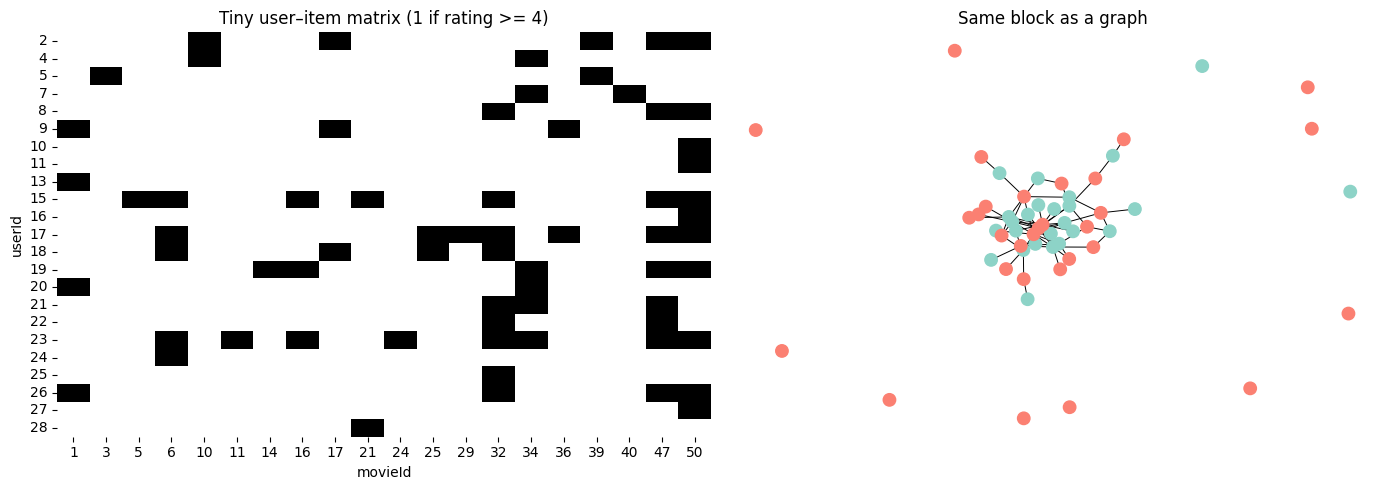

In [4]:
# Side-by-side: sparse matrix vs graph for a tiny block
tiny_users = sorted(pos_small['userId'].unique())[:25]
tiny_items = sorted(pos_small['movieId'].unique())[:30]
tiny = pos_small[pos_small['userId'].isin(
    tiny_users) & pos_small['movieId'].isin(tiny_items)]

ui = pd.crosstab(tiny['userId'], tiny['movieId']).astype(int)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ui, cmap='Greys', cbar=False, ax=ax1)
ax1.set_title('Tiny user–item matrix (1 if rating >= 4)')
ax1.set_xlabel('movieId')
ax1.set_ylabel('userId')

S2 = nx.Graph()
S2.add_nodes_from(['u_'+str(u) for u in tiny_users], bipartite='users')
S2.add_nodes_from(['m_'+str(i) for i in tiny_items], bipartite='items')
S2.add_edges_from([('u_'+str(u), 'm_'+str(i))
                  for u, i in tiny[['userId', 'movieId']].values])
pos2 = nx.spring_layout(S2, seed=SEED)
colors2 = ['#8dd3c7' if S2.nodes[n].get(
    'bipartite') == 'users' else '#fb8072' for n in S2.nodes]
nx.draw(S2, pos2, node_size=80, node_color=colors2, width=0.7, ax=ax2)
ax2.set_title('Same block as a graph')
plt.tight_layout()

### Matrix vs Graph lens — when each helps

- Matrix view: great for linear algebra and classical MF; hides topology (who is near whom via paths).
- Graph view: surfaces neighborhoods, hubs, and multi-hop trails that drive collaborative effects.
- Why GNNs help: embeddings can mix neighbor information layer-by-layer, aligning more with real consumption patterns.


## 3) From Embeddings to Graph Neural Networks

In Part 1, we explored how to learn embeddings for users and items. However, a key limitation of those methods is that they often learn these representations in isolation, without explicitly considering the rich structure of the user-item interaction graph. For instance, two similar items that happen to be rated by few of the same users might have their embeddings drift apart, even if they are conceptually related.

This is where Graph Neural Networks (GNNs) introduce a powerful innovation: **message passing**. The core idea is that each node in the graph can update its own embedding by aggregating information from its direct neighbors. By repeating this process over multiple "hops," a node's embedding can incorporate signals from its extended neighborhood (e.g., friends of friends). This captures the intuitive notion that an entity's identity is shaped by its connections.

To build intuition, we'll start with a simple demonstration of this neighbor-averaging process on a small, toy graph. Then, we'll scale up and implement a LightGCN-style propagation layer for our MovieLens dataset.

In [5]:
# Toy message passing on a mini bipartite graph
toy_users = ['u1','u2']
toy_items = ['i1','i2','i3']
toy_edges = [('u1','i1'), ('u1','i2'), ('u2','i2'), ('u2','i3')]

# Initial random embeddings
dim = 4
emb = {n: torch.randn(dim) for n in toy_users + toy_items}

def one_round_neighbor_mean(emb, edges):
    nbrs = {n: [] for n in emb}
    for u,i in edges:
        nbrs[u].append(i); nbrs[i].append(u)
    new = {}
    for n in emb:
        if len(nbrs[n]) == 0:
            new[n] = emb[n].clone()
        else:
            new[n] = torch.stack([emb[k] for k in nbrs[n]]).mean(dim=0)
    return new

print('Before:', {k: v.tolist() for k,v in emb.items()})
emb = one_round_neighbor_mean(emb, toy_edges)
print('After one round:', {k: v.tolist() for k,v in emb.items()})

Before: {'u1': [0.33669036626815796, 0.12880940735340118, 0.23446236550807953, 0.23033303022384644], 'u2': [-1.1228563785552979, -0.18632829189300537, 2.2082014083862305, -0.637997031211853], 'i1': [0.46165722608566284, 0.2673508822917938, 0.5349046587944031, 0.809357225894928], 'i2': [1.110290288925171, -1.6897989511489868, -0.9889599084854126, 0.9579718112945557], 'i3': [1.322135090827942, 0.8171897530555725, -0.765838623046875, -0.7506223320960999]}
After one round: {'u1': [0.7859737873077393, -0.7112240195274353, -0.22702762484550476, 0.8836644887924194], 'u2': [1.2162127494812012, -0.43630459904670715, -0.8773992657661438, 0.1036747395992279], 'i1': [0.33669036626815796, 0.12880940735340118, 0.23446236550807953, 0.23033303022384644], 'i2': [-0.39308300614356995, -0.028759442269802094, 1.2213318347930908, -0.2038320004940033], 'i3': [-1.1228563785552979, -0.18632829189300537, 2.2082014083862305, -0.637997031211853]}


## 4) LightGCN for recommendations

Why LightGCN? It's a simplified but strong GNN for collaborative filtering: no feature transforms, no activations — just multi-layer neighborhood aggregation on the user–item graph, then averaging the embeddings across layers.

We'll implement a minimal LightGCN-style propagation without extra libraries: build a normalized adjacency, propagate K hops, and use dot products for scoring.

In [6]:
# Build normalized adjacency for the bipartite graph and a minimal LightGCN-like model
from collections import defaultdict

# --- 1. ID Mapping and Matrix Construction ---
# We need to map raw user/movie IDs to zero-based integer indices
# for use with embedding layers and matrix operations.
u_ids = sorted(pos_small['userId'].unique())
i_ids = sorted(pos_small['movieId'].unique())
u2idx = {u: i for i, u in enumerate(u_ids)}
i2idx = {i: j for j, i in enumerate(i_ids)}

# Create the user-item interaction matrix (R) in sparse format.
# '1' indicates a positive interaction (rating >= 3.5).
rows = [u2idx[u] for u in pos_small['userId'].values]
cols = [i2idx[i] for i in pos_small['movieId'].values]
data = np.ones(len(rows), dtype=np.float32)
R = sparse.coo_matrix((data, (rows, cols)), shape=(
    len(u_ids), len(i_ids))).tocsr()

# --- 2. Build the Full Bipartite Adjacency Matrix (A) ---
# LightGCN operates on the entire user-item graph. We build a single
# adjacency matrix 'A' of shape (num_users + num_items, num_users + num_items).
# It looks like:
# [ 0 | R ]
# [ R^T | 0 ]
U, I = R.shape
upper = sparse.hstack([sparse.csr_matrix((U, U)), R])
lower = sparse.hstack([R.T, sparse.csr_matrix((I, I))])
A = sparse.vstack([upper, lower]).tocsr()

# --- 3. Symmetric Normalization of Adjacency Matrix ---
# This is a key step in GCN-based models to stabilize learning.
# We compute A_norm = D^(-1/2) * A * D^(-1/2), where D is the diagonal degree matrix.
# This prevents embeddings from scaling uncontrollably during propagation.
deg = np.asarray(A.sum(axis=1)).flatten()
d_inv_sqrt = 1.0 / np.sqrt(np.clip(deg, 1e-12, None))  # Add epsilon for stability
D_inv_sqrt = sparse.diags(d_inv_sqrt)
A_norm = D_inv_sqrt @ A @ D_inv_sqrt


# Helper to convert a SciPy sparse matrix to a PyTorch sparse tensor.
def scipy_to_torch_sparse(mat):
    mat = mat.tocoo()
    indices = torch.tensor(np.vstack((mat.row, mat.col)), dtype=torch.long)
    values = torch.tensor(mat.data, dtype=torch.float32)
    shape = torch.Size(mat.shape)
    return torch.sparse_coo_tensor(indices, values, shape).coalesce()


# Convert our normalized adjacency matrix to a PyTorch tensor for the model.
A_norm_t = scipy_to_torch_sparse(A_norm)
N = A_norm.shape[0]  # Total number of nodes (users + items)

In [7]:
# --- 4. A Simple LightGCN Model Implementation ---
class LightGCNSimple(nn.Module):
    def __init__(self, num_nodes, embed_dim=64, num_layers=3):
        super().__init__()
        # A single embedding layer for all users and items.
        self.E = nn.Embedding(num_nodes, embed_dim)
        # Initialize with small random values
        nn.init.normal_(self.E.weight, std=0.1)
        self.num_layers = num_layers

    def propagate(self, A_norm):
        # This is the core message-passing mechanism.
        x = self.E.weight  # Start with initial embeddings (layer 0)
        out = [x]
        # Propagate information across the graph for 'num_layers' hops.
        for _ in range(self.num_layers):
            # Each multiplication aggregates neighbor information.
            x = torch.sparse.mm(A_norm, x)
            out.append(x)
        # The final embedding is the average of embeddings from all layers.
        return torch.stack(out, dim=0).mean(dim=0)

    def forward(self, A_norm):
        # The forward pass simply performs the propagation.
        return self.propagate(A_norm)

In [8]:
# --- 5. Recommendation Generation Function ---
def recommend_for_user(user_raw_id, model, A_norm, topk=10, exclude_seen=True):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        # Get the final, propagated embeddings for all nodes.
        Z = model(A_norm)  # N x d
        # Split embeddings back into users and items.
        U_emb = Z[:U]
        I_emb = Z[U:]

        # Get the specific user's embedding vector.
        u_idx = u2idx[user_raw_id]
        u_vec = U_emb[u_idx:u_idx+1]  # 1 x d

        # Compute scores as the dot product between the user and all item embeddings.
        scores = (u_vec @ I_emb.T).squeeze(0)  # num_items
        scores = scores.cpu().numpy()

        # Optionally, filter out items the user has already interacted with.
        if exclude_seen:
            seen = set(pos_small[pos_small['userId'] == user_raw_id]['movieId'])
            seen_idx = [i2idx[i] for i in seen if i in i2idx]
            scores[seen_idx] = -np.inf  # Set score to negative infinity

        # Get the indices of the top-k items.
        top_idx = np.argpartition(-scores, range(min(topk, len(scores))))[:topk]
        # Sort the top-k by score
        top_idx = top_idx[np.argsort(-scores[top_idx])]

        # Map indices back to raw movie IDs.
        top_items = [i_ids[j] for j in top_idx]
        return list(zip(top_items, scores[top_idx]))


# Instantiate the model.
model = LightGCNSimple(num_nodes=N, embed_dim=64, num_layers=3)
print(model)

LightGCNSimple(
  (E): Embedding(245, 64)
)


### Message Passing Intuition

The intuition behind message passing is straightforward. In each round, a node's embedding vector is updated by aggregating the embeddings of its immediate neighbors. When this process is repeated for K rounds, a node's final embedding effectively encodes information from its K-hop neighborhood. This is how the model captures complex collaborative effects, such as "users who like items that were also liked by similar users."

LightGCN simplifies this process elegantly. It dispenses with the feature transformations (MLPs) and non-linear activation functions common in other GNNs. Instead, it relies purely on neighbor aggregation and then averages the embeddings generated at each layer. However, there's a key trade-off: while more layers can capture more distant relationships, too many can lead to **over-smoothing**, where all node embeddings become indistinguishable. For this reason, a stack of 2-3 layers is often a practical and effective

### Optional: quick BPR training loop (few epochs)

LightGCN is typically trained with a ranking loss like **Bayesian Personalized Ranking (BPR)**. The core idea of BPR is to optimize the model so that it predicts a higher score for a positive item (one the user has interacted with) than for a negative item (one they haven't). For each user, we sample a `(user, positive_item, negative_item)` triplet, and the loss function encourages the model to rank the positive item higher. We'll do a tiny run to refine the embeddings, keeping it small to run fast.


In [9]:
# Build user->positives for negative sampling
user_pos = defaultdict(set)
for u, i in pos_small[['userId', 'movieId']].values:
    user_pos[u].add(i)

all_items_list = list(i_ids)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-6)


def sample_batch(batch_size=2048):
    users = np.random.choice(u_ids, size=batch_size, replace=True)
    pos_items = []
    neg_items = []
    for u in users:
        p = random.choice(list(user_pos[u]))
        # sample negative not in positives
        n = random.choice(all_items_list)
        tries = 0
        while n in user_pos[u] and tries < 10:
            n = random.choice(all_items_list)
            tries += 1
        pos_items.append(p)
        neg_items.append(n)
    u_idx = torch.tensor([u2idx[u] for u in users], dtype=torch.long)
    p_idx = torch.tensor([i2idx[i] for i in pos_items], dtype=torch.long)
    n_idx = torch.tensor([i2idx[i] for i in neg_items], dtype=torch.long)
    return u_idx, p_idx, n_idx


def bpr_loss(u_e, i_e_pos, i_e_neg, reg=1e-4):
    pos_scores = (u_e * i_e_pos).sum(dim=1)
    neg_scores = (u_e * i_e_neg).sum(dim=1)
    loss = -F.logsigmoid(pos_scores - neg_scores).mean()
    loss = loss + reg*(u_e.pow(2).mean() + i_e_pos.pow(2).mean() + i_e_neg.pow(2).mean())
    return loss


epochs = 100
A_norm_t = A_norm_t.coalesce()  # ensure coalesced for fast mm
for ep in range(1, epochs+1):
    model.train()
    u_idx, p_idx, n_idx = sample_batch(batch_size=4096)
    Z = model(A_norm_t)
    U_emb = Z[:U]  # users
    I_emb = Z[U:]  # items
    loss = bpr_loss(U_emb[u_idx], I_emb[p_idx], I_emb[n_idx])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if ep % 5 == 0:
        print(f'Epoch {ep}/{epochs} - BPR loss: {loss.item():.4f}')

Epoch 5/100 - BPR loss: 0.6462
Epoch 10/100 - BPR loss: 0.5653
Epoch 15/100 - BPR loss: 0.4543
Epoch 20/100 - BPR loss: 0.3329
Epoch 25/100 - BPR loss: 0.2318
Epoch 30/100 - BPR loss: 0.1726
Epoch 35/100 - BPR loss: 0.1324
Epoch 40/100 - BPR loss: 0.1054
Epoch 45/100 - BPR loss: 0.0904
Epoch 50/100 - BPR loss: 0.0692
Epoch 55/100 - BPR loss: 0.0685
Epoch 60/100 - BPR loss: 0.0577
Epoch 65/100 - BPR loss: 0.0493
Epoch 70/100 - BPR loss: 0.0464
Epoch 75/100 - BPR loss: 0.0358
Epoch 80/100 - BPR loss: 0.0348
Epoch 85/100 - BPR loss: 0.0292
Epoch 90/100 - BPR loss: 0.0292
Epoch 95/100 - BPR loss: 0.0266
Epoch 100/100 - BPR loss: 0.0221


In [10]:
# Quick recommendations for a few users
sampled_users = random.sample(u_ids, k=min(3, len(u_ids)))
for ur in sampled_users:
    print(f"\nRecommendations for user {ur}:")
    seen_titles = movies[movies['movieId'].isin(list(user_pos[ur]))]['title'].tolist()[:5]
    print(f'  Seen (first 5): {seen_titles}\n')
    recs = recommend_for_user(ur, model, A_norm_t, topk=5, exclude_seen=True)
    titles = movies[movies['movieId'].isin([i for i,_ in recs])][['movieId','title']]
    for mid, score in recs:
        title = titles[titles['movieId']==mid]['title'].values
        title = title[0] if len(title)>0 else str(mid)
        print(f"  {title} (score: {score:.4f})")


Recommendations for user 37:
  Seen (first 5): ['Toy Story (1995)', 'Lion King, The (1994)']

  Forrest Gump (1994) (score: 4.2696)
  Shawshank Redemption, The (1994) (score: 3.3721)
  Miracle on 34th Street (1994) (score: 3.3493)
  Batman Forever (1995) (score: 3.3280)
  Babe (1995) (score: 3.1812)

Recommendations for user 20:
  Seen (first 5): ['Toy Story (1995)', 'Babe (1995)', 'Muppet Treasure Island (1996)', 'Batman Forever (1995)', 'Stargate (1994)']

  Forrest Gump (1994) (score: 6.6113)
  Braveheart (1995) (score: 5.7209)
  Pulp Fiction (1994) (score: 5.7131)
  Twelve Monkeys (a.k.a. 12 Monkeys) (1995) (score: 4.6839)
  Jurassic Park (1993) (score: 4.4949)

Recommendations for user 4:
  Seen (first 5): ['GoldenEye (1995)', 'Babe (1995)', 'Rumble in the Bronx (Hont faan kui) (1995)', 'Birdcage, The (1996)', 'Batman Forever (1995)']

  Braveheart (1995) (score: 8.2791)
  While You Were Sleeping (1995) (score: 6.7556)
  Toy Story (1995) (score: 6.5172)
  Outbreak (1995) (score: 

## 5) Implementation preview: PyTorch Geometric basics

PyTorch Geometric (PyG) provides friendly primitives for graphs. Below, we show how our bipartite edges map to the inputs that a recommender model like LightGCN expects. If PyG is installed, we'll run a tiny forward pass; otherwise, you'll see instructions to enable it.

In [11]:
try:
    from torch_geometric.nn.models.lightgcn import LightGCN
    import torch_geometric
    print('PyG version:', torch_geometric.__version__)

    # Build edge_index as user->item pairs for LightGCN
    # PyG's LightGCN expects edge_index of shape [2, num_edges]
    # with rows [user_index, item_index + num_users] to share a single index space.
    ui_edges = np.vstack([rows, np.array(cols) + U])  # shape [2, E]
    edge_index = torch.tensor(ui_edges, dtype=torch.long)
    # Make undirected by concatenating reversed edges
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    pyg_model = LightGCN(num_nodes=U+I, embedding_dim=64, num_layers=3)
    with torch.no_grad():
        out = pyg_model(edge_index)  # (U+I) x d
        print('PyG LightGCN forward ok. Embeddings shape:', tuple(out.shape))
except Exception as e:
    print('PyTorch Geometric not available. To try it locally:')
    print('- Install CPU wheels from https://data.pyg.org/ with a torch-compatible build')
    print('- Then: pip install torch-geometric')
    print('Reason:', str(e))

PyG version: 2.6.1
PyG LightGCN forward ok. Embeddings shape: (1260,)


## 6) Real-world success: Pinterest PinSage

- Scale: billions of nodes and tens of billions of edges
- Key ideas: smart random-walk sampling, neighborhood importance weighting, mini-batch training
- Business impact: strong gains in engagement and retrieval quality at web scale

References to explore:
- PinSage paper (Ying et al., 2018): https://arxiv.org/abs/1806.01973
- Engineering talks/blogs from Pinterest on production graph recommenders
- Related: LightGCN (He et al., 2020), GraphSAGE, GAT for recommendation

## Key takeaways and next steps

- Graphs offer a natural view of user–item interactions as a bipartite network
- LightGCN refines embeddings by propagating signals over multiple hops
- Link prediction with dot products yields practical recommendations
- PyG gives convenient graph data structures and models when you need them

Next: You’ll build a practical GNN-based content search/retrieval module in the final exercise.